Bank Loan Analysis – Python EDA

Dataset: 38,576 loan records
Features: 24 variables
Tools: Python (Pandas, Seaborn, Matplotlib)
Objective: Analyze loan performance, borrower risk segments, and lending trends.

In [1]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [2]:
df=pd.read_csv('financial_loan.csv')

In [3]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


Basic Dataset Overview

In [6]:
df.shape

(38576, 24)

In [7]:
df.columns

Index(['id', 'address_state', 'application_type', 'emp_length', 'emp_title',
       'grade', 'home_ownership', 'issue_date', 'last_credit_pull_date',
       'last_payment_date', 'loan_status', 'next_payment_date', 'member_id',
       'purpose', 'sub_grade', 'term', 'verification_status', 'annual_income',
       'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc',
       'total_payment'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  str    
 2   application_type       38576 non-null  str    
 3   emp_length             38576 non-null  str    
 4   emp_title              37138 non-null  str    
 5   grade                  38576 non-null  str    
 6   home_ownership         38576 non-null  str    
 7   issue_date             38576 non-null  str    
 8   last_credit_pull_date  38576 non-null  str    
 9   last_payment_date      38576 non-null  str    
 10  loan_status            38576 non-null  str    
 11  next_payment_date      38576 non-null  str    
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  str    
 14  sub_grade              38576 non-null  str    
 15  term         

In [9]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


Check Missing Values

In [10]:
df.isnull().sum()

id                          0
address_state               0
application_type            0
emp_length                  0
emp_title                1438
grade                       0
home_ownership              0
issue_date                  0
last_credit_pull_date       0
last_payment_date           0
loan_status                 0
next_payment_date           0
member_id                   0
purpose                     0
sub_grade                   0
term                        0
verification_status         0
annual_income               0
dti                         0
installment                 0
int_rate                    0
loan_amount                 0
total_acc                   0
total_payment               0
dtype: int64

In [12]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

id                       0.000000
address_state            0.000000
application_type         0.000000
emp_length               0.000000
emp_title                3.727706
grade                    0.000000
home_ownership           0.000000
issue_date               0.000000
last_credit_pull_date    0.000000
last_payment_date        0.000000
loan_status              0.000000
next_payment_date        0.000000
member_id                0.000000
purpose                  0.000000
sub_grade                0.000000
term                     0.000000
verification_status      0.000000
annual_income            0.000000
dti                      0.000000
installment              0.000000
int_rate                 0.000000
loan_amount              0.000000
total_acc                0.000000
total_payment            0.000000
dtype: float64

Loan Status Distribution

In [15]:
df['loan_status'].value_counts()

loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64

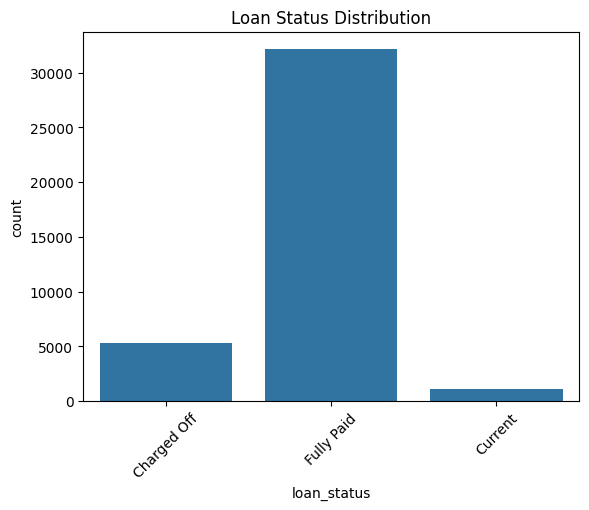

In [16]:
sns.countplot(x='loan_status', data=df)
plt.xticks(rotation=45)
plt.title("Loan Status Distribution")
plt.show()

Insight:

Most loans fall under the Fully Paid category, indicating a high repayment rate. However, a smaller proportion of loans fall under Charged Off, representing potential default risk segments.

Loan Amount Distribution

<Axes: xlabel='loan_amount', ylabel='Count'>

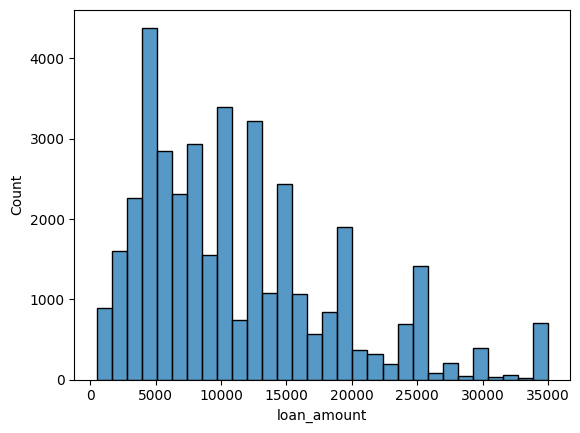

In [26]:
sns.histplot(df['loan_amount'], bins=30)

Insight:

Loan amounts are concentrated within the mid-range values, indicating that borrowers generally request moderate loan amounts rather than extremely high loans.

Loan Amount by Purpose

In [17]:
df.groupby('purpose')['loan_amount'].mean().sort_values(ascending=False)

purpose
small business        13582.826577
house                 13182.855191
Debt consolidation    12762.692160
credit card           11781.747699
home improvement      11596.236092
wedding                9941.594828
renewable_energy       8997.340426
medical                8295.689655
major purchase         8176.113744
other                  8147.424163
educational            6862.380952
car                    6829.375418
moving                 6705.053667
vacation               5590.767045
Name: loan_amount, dtype: float64

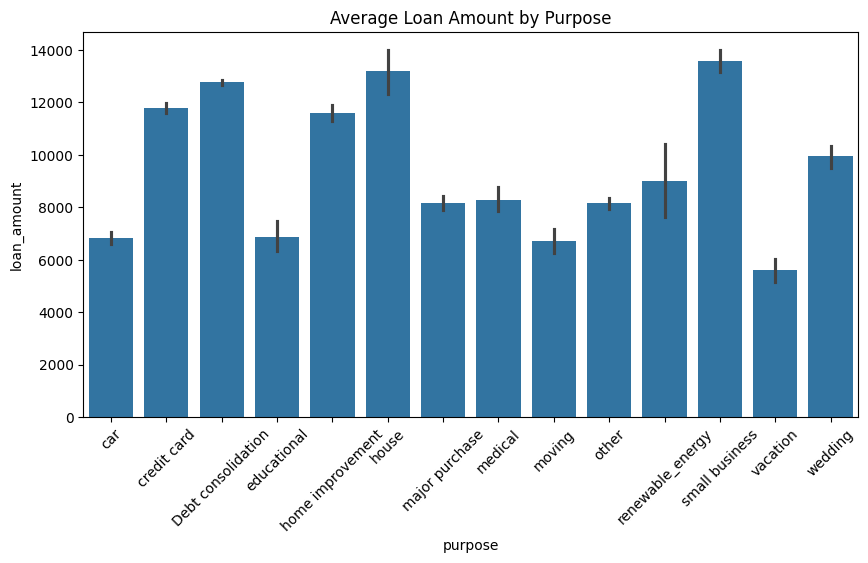

In [18]:
plt.figure(figsize=(10,5))
sns.barplot(x='purpose', y='loan_amount', data=df)
plt.xticks(rotation=45)
plt.title("Average Loan Amount by Purpose")
plt.show()

Insight:

Loans for small business and house represent a large portion of the lending volume, suggesting these are the most common borrowing purposes.

Income vs Loan Amount

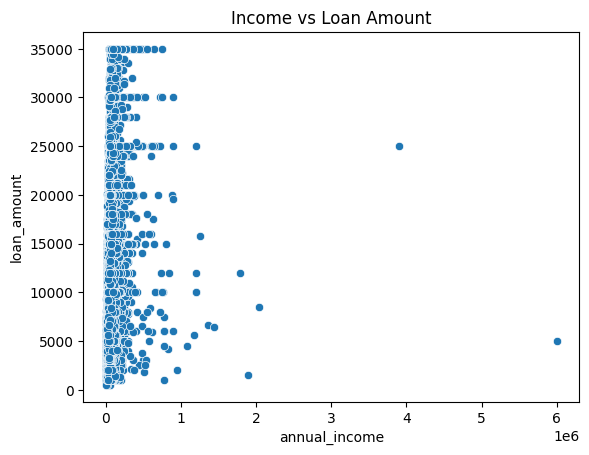

In [20]:
sns.scatterplot(x='annual_income', y='loan_amount', data=df)
plt.title("Income vs Loan Amount")
plt.show()

Insight: 

Borrowers with higher annual income generally tend to take larger loan amounts, indicating a positive relationship between income level and loan size.

Default Risk by Credit Grade

In [21]:
df.groupby('grade')['loan_status'].value_counts()

grade  loan_status
A      Fully Paid      9102
       Charged Off      552
       Current           35
B      Fully Paid     10004
       Charged Off     1343
       Current          327
C      Fully Paid      6381
       Charged Off     1266
       Current          257
D      Fully Paid      3894
       Charged Off     1072
       Current          216
E      Fully Paid      1920
       Charged Off      691
       Current          175
F      Fully Paid       646
       Charged Off      311
       Current           71
G      Fully Paid       198
       Charged Off       98
       Current           17
Name: count, dtype: int64

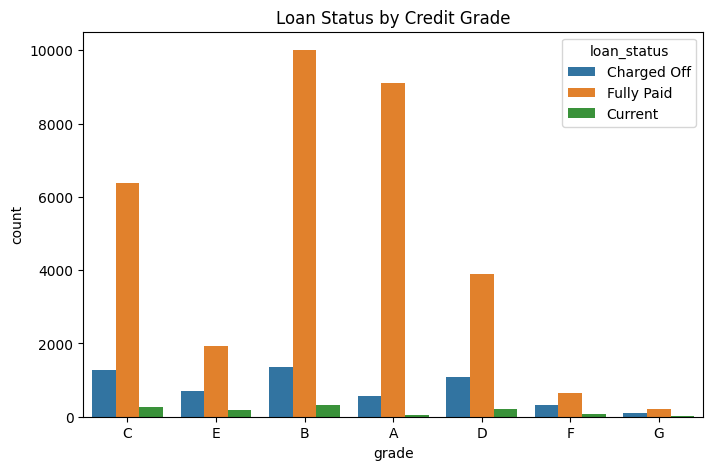

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(x='grade', hue='loan_status', data=df)
plt.title("Loan Status by Credit Grade")
plt.show()

Insight: 

Identifies riskier borrower grades.

Debt-to-Income Ratio Analysis

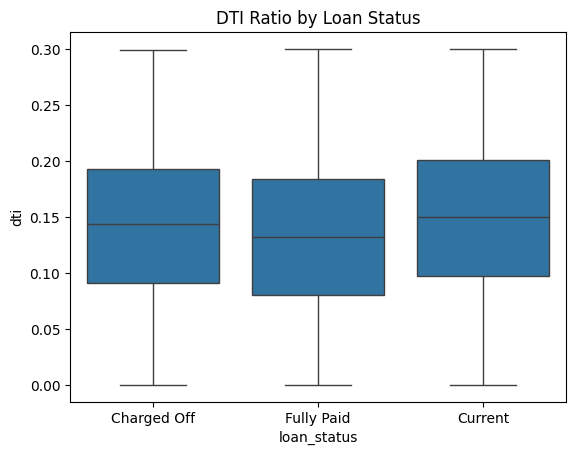

In [23]:
sns.boxplot(x='loan_status', y='dti', data=df)
plt.title("DTI Ratio by Loan Status")
plt.show()

Insight:

High DTI often correlates with loan defaults.

Home Ownership vs Loan Status

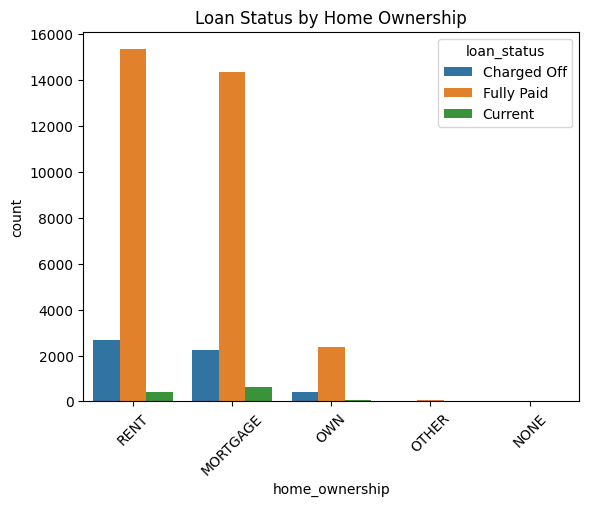

In [24]:
sns.countplot(x='home_ownership', hue='loan_status', data=df)
plt.xticks(rotation=45)
plt.title("Loan Status by Home Ownership")
plt.show()

Insight: 

Shows borrower profile differences.

Final Key Insights:
Majority of loans fall under Fully Paid, indicating strong repayment behavior.
Borrowers with lower credit grades show higher default risk.
Debt consolidation and small business loans represent major borrowing purposes.
Higher DTI ratios are associated with increased loan default probability.
Borrowers with higher income tend to take larger loan amounts.